In [1]:
import sklearn
print(sklearn.__version__)

1.8.0


In [2]:
pip install --upgrade scikit-learn joblib

1.Importing the independencies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set a unique visual style for all plots
sns.set_theme(style="darkgrid") # Using darkgrid for a modern look
custom_palette = sns.color_palette("husl", 8) # Using HUSL palette for vibrant colors
sns.set_palette(custom_palette)

2.Data cleaning

In [4]:
# Load dataset
df = pd.read_csv('chronic_disease_prediction_dataset.csv')

# Drop unnecessary columns
df.drop('Patient_ID', axis=1, inplace=True)

# Encode target variable
df['HasChronicDisease'] = df['HasChronicDisease'].map({'Yes': 1, 'No': 0})

# Check for nulls (optional but safe)
df.dropna(inplace=True)

3.Data visualization

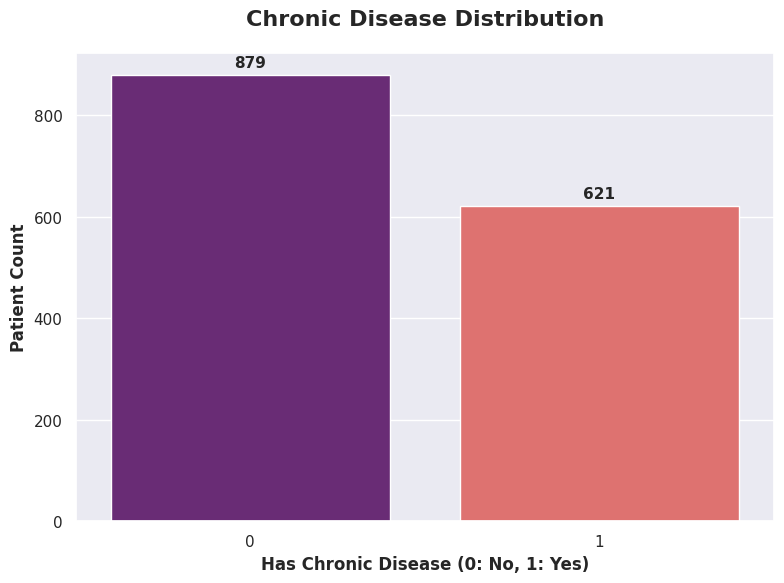

In [5]:
# Target Distribution with Bold Colors
plt.figure(figsize=(8, 6))
# Using 'hue' to avoid the warning and 'magma' for an attractive look
ax = sns.countplot(x='HasChronicDisease', data=df, hue='HasChronicDisease', palette='magma', legend=False)

plt.title('Chronic Disease Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Has Chronic Disease (0: No, 1: Yes)', fontsize=12, fontweight='bold')
plt.ylabel('Patient Count', fontsize=12, fontweight='bold')

# Adding count labels on top of bars for better detailing
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9),
                textcoords = 'offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

4.Exploratory Data Analysis (EDA)

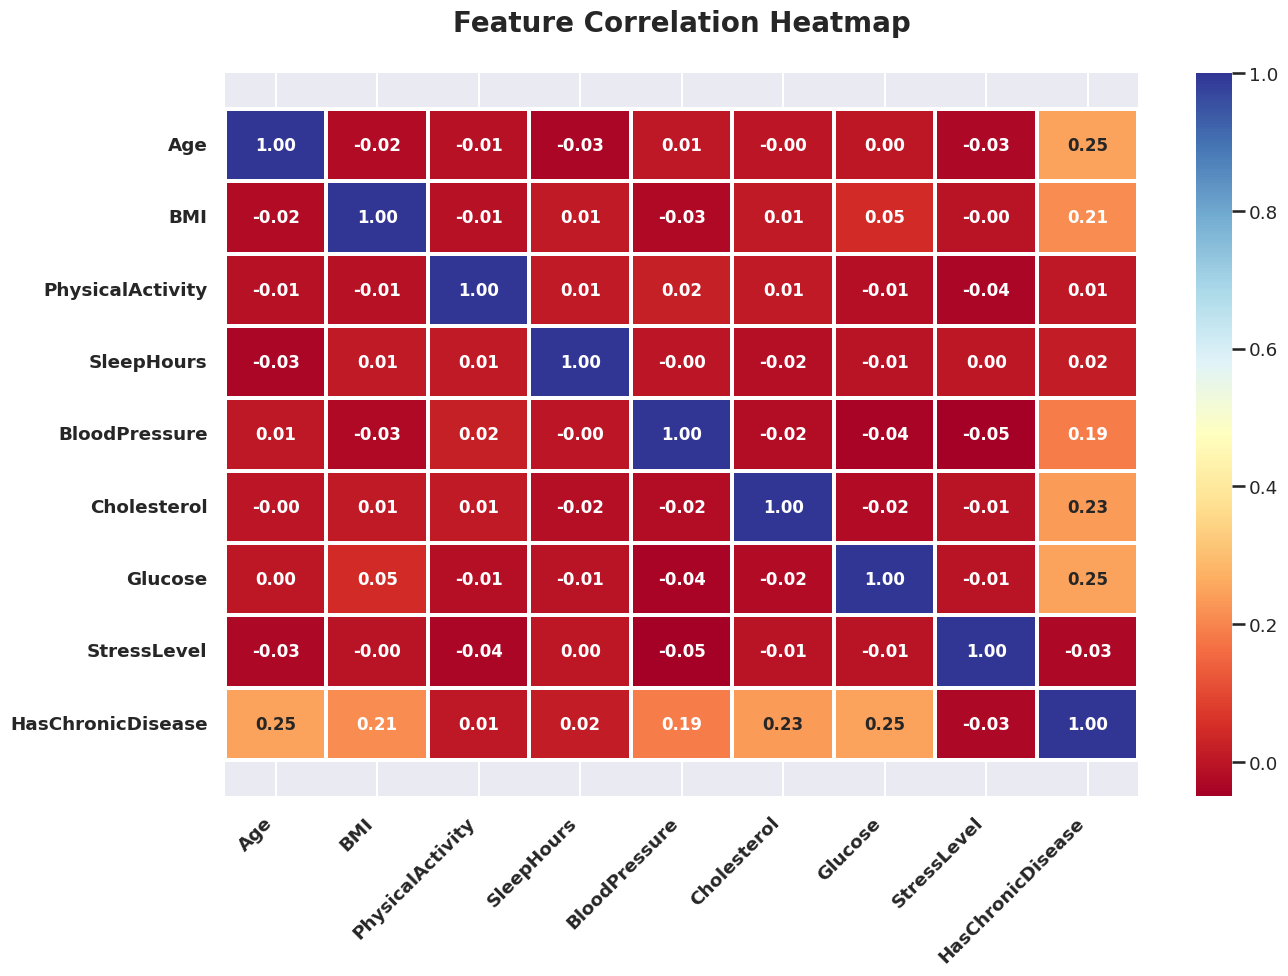

In [6]:

# Setting the context for bold and clear labels
sns.set_context("talk", font_scale=0.8)
plt.figure(figsize=(14, 10))

# Selecting only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Professional Heatmap with bold styling
# cmap='RdYlBu' gives a high-contrast professional look
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 cmap='RdYlBu',
                 fmt=".2f",
                 linewidths=1.5,
                 linecolor='white',
                 annot_kws={"size": 12, "weight": "bold"})

# --- CRITICAL FIX FOR CUT-OFF EDGES ---
# Manually getting the limits and adding a 0.5 buffer to show full cells
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
# --------------------------------------

# Formatting Labels to be Bold
plt.title('Feature Correlation Heatmap', fontsize=20, fontweight='bold', pad=30)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')

# Ensures everything fits perfectly within the saved image
plt.tight_layout()
plt.show()

5.Data Modeling Preparation

In [7]:
# Identifying numerical and categorical columns
categorical_cols = ['Gender', 'Smoking', 'AlcoholIntake', 'DietQuality', 'FamilyHistory']
numerical_cols = ['Age', 'BMI', 'PhysicalActivity', 'SleepHours', 'BloodPressure', 'Cholesterol', 'Glucose', 'StressLevel']

6.Splitting the data into features and targets

In [8]:
X = df.drop('HasChronicDisease', axis=1)
y = df['HasChronicDisease']

7.Splitting the data into test and training data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.Model Training

In [10]:
# Building a classifier (Random Forest as an example)
model = RandomForestClassifier(n_estimators=100, random_state=42)

9.Model Evaluation

In [11]:
# Note: For evaluation, we will use a temporary pipeline to ensure data is transformed
temp_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Fit on training and evaluate
X_train_transformed = temp_preprocessor.fit_transform(X_train)
X_test_transformed = temp_preprocessor.transform(X_test)

model.fit(X_train_transformed, y_train)
y_pred = model.predict(X_test_transformed)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9433333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       167
           1       0.98      0.89      0.93       133

    accuracy                           0.94       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.94      0.94       300



10.Communication and Visualization

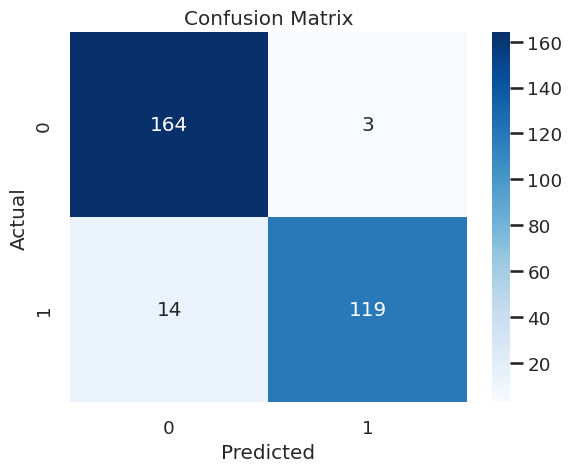

In [12]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

11.Model saving (.sav format)

In [13]:
# Saving the trained model specifically
joblib.dump(model, 'chronic_disease_model.sav')
print("Model saved as chronic_disease_model.sav")

Model saved as chronic_disease_model.sav


12.Data automated pipeline implementation

In [14]:
# Define the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create the final automated pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Training the full pipeline
clf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

13.Pipeline saving

In [15]:
# Saving the whole pipeline in a compressed format
joblib.dump(clf_pipeline, 'full_pipeline_compressed.sav', compress=3)
print("Compressed pipeline saved as full_pipeline_compressed.sav")

Compressed pipeline saved as full_pipeline_compressed.sav
